# Assignment - Group Activity
**Course:** Python for Data Analytics  
**Students**
* Reiman Munoz NF1011566
* Durjoy Roy
* Bruno Sassi
* Zainab Taiwo

**Date:** Septiembre 09/ 2025  
**Instructor:** Milad Rezamand  


# STEP 1:

* Mount Google Drive
* Import libraries
* Load Dataset
* Preview Dataset

In [17]:
#from google.colab import drive
#drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#file_path = '/content/drive/MyDrive/Colab Notebooks/Python/recipe_reviews.csv'
df = pd.read_csv('hotel_booking_info.csv')

print(" Dataset loaded successfully!")
print(" Shape:", df.shape)
display(df.head())
df.info()



 Dataset loaded successfully!
 Shape: (87396, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,no,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,no,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,no,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,no,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,no,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,7/3/2015


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  object 
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

  reservation_status_date  reservation_day  reservation_week  \
0              2015-07-01                1                27   
1              2015-07-01                1                27   
2              2015-07-02                2                27   
3              2015-07-02                2                27   
4              2015-07-03                3                27   

   reservation_month  reservation_year  
0                  7              2015  
1                  7              2015  
2                  7              2015  
3                  7              2015  
4                  7              2015  


# Data Cleaning

* Convert appropriate columns to numeric if needed
* Check for missing values
* Drop duplicate rows
* Check data types
* Preview cleaned data



In [37]:
# Change date columns to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Extract day, week, month, and year
df['reservation_day'] = df['reservation_status_date'].dt.day
df['reservation_week'] = df['reservation_status_date'].dt.isocalendar().week
df['reservation_month'] = df['reservation_status_date'].dt.month
df['reservation_year'] = df['reservation_status_date'].dt.year

# Check the results
print(df[['reservation_status_date', 'reservation_day', 'reservation_week', 'reservation_month', 'reservation_year']].head())


  reservation_status_date  reservation_day  reservation_week  \
0              2015-07-01                1                27   
1              2015-07-01                1                27   
2              2015-07-02                2                27   
3              2015-07-02                2                27   
4              2015-07-03                3                27   

   reservation_month  reservation_year  
0                  7              2015  
1                  7              2015  
2                  7              2015  
3                  7              2015  
4                  7              2015  


In [18]:


df.replace("2", np.nan, inplace=True)

for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        continue


print("🧼 Missing values per column:")
print(df.isnull().sum())

if 'star_rating' in df.columns:
    df.dropna(subset=['star_rating'], inplace=True)

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f" Removed {before - after} duplicate rows.")

print("\n Data types:")
print(df.dtypes)

df.head()

🧼 Missing values per column:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,no,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,no,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,no,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,no,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,no,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [19]:
# check unique values in each column
for i in df.select_dtypes(include=['object']).columns:
    print(f"\n Unique values in '{i}':")
    print(df[i].value_counts())


 Unique values in 'hotel':
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

 Unique values in 'is_canceled':
is_canceled
no     63371
yes    24025
Name: count, dtype: int64

 Unique values in 'arrival_date_month':
arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

 Unique values in 'meal':
meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

 Unique values in 'country':
country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
       ...  
MMR        1
BFA        1
CYM        1
MLI        1
KHM        1
Name: count, Length: 178, dtype: int64

 Unique values in 'market_segment':
market_segment
Online TA        51618
Offline TA/TO    13889
Direct       

In [23]:
# drop undefined rows for 'market_segment' 'distribution_channel'
df = df[~df['market_segment'].isin(['Undefined'])]
df = df[~df['distribution_channel'].isin(['Undefined'])]
df = df[~df['meal'].isin(['Undefined'])]

print(df.columns)

df.shape

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


(86899, 32)

# Exploratory Data Analysis (EDA)

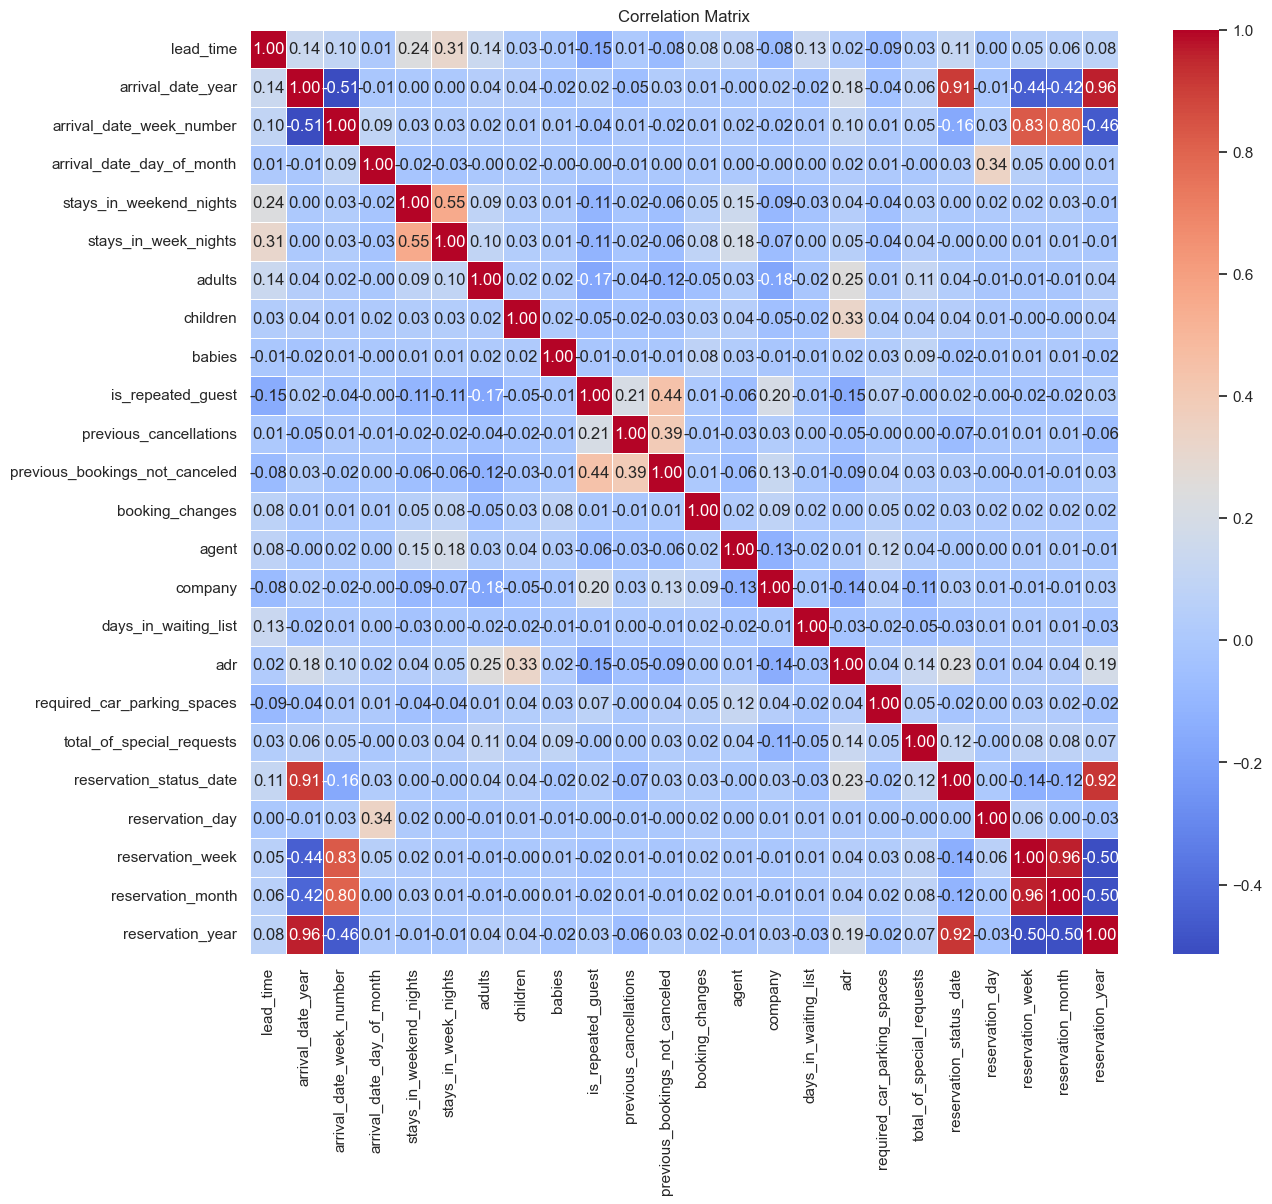

In [41]:
# Compute the correlation matrix
corr = df[df.select_dtypes(exclude=['object']).columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


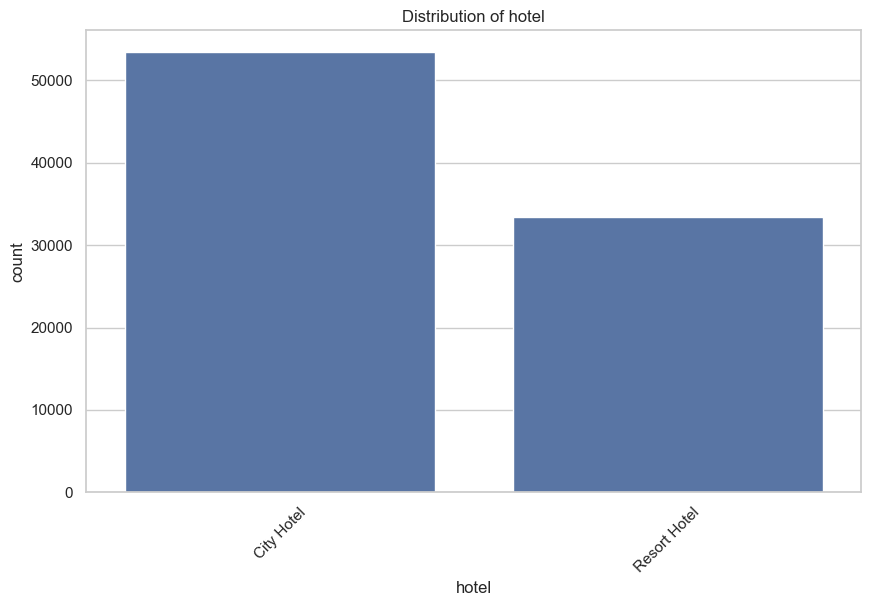

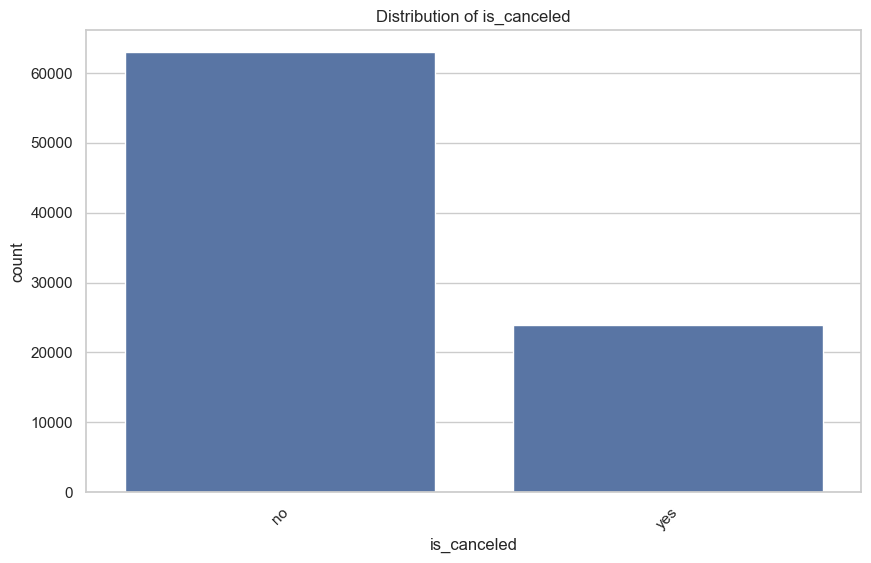

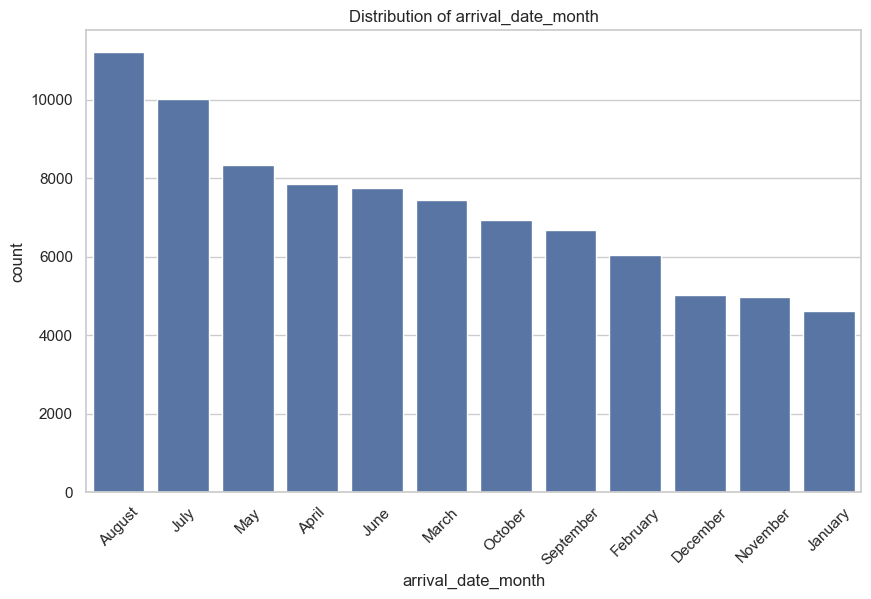

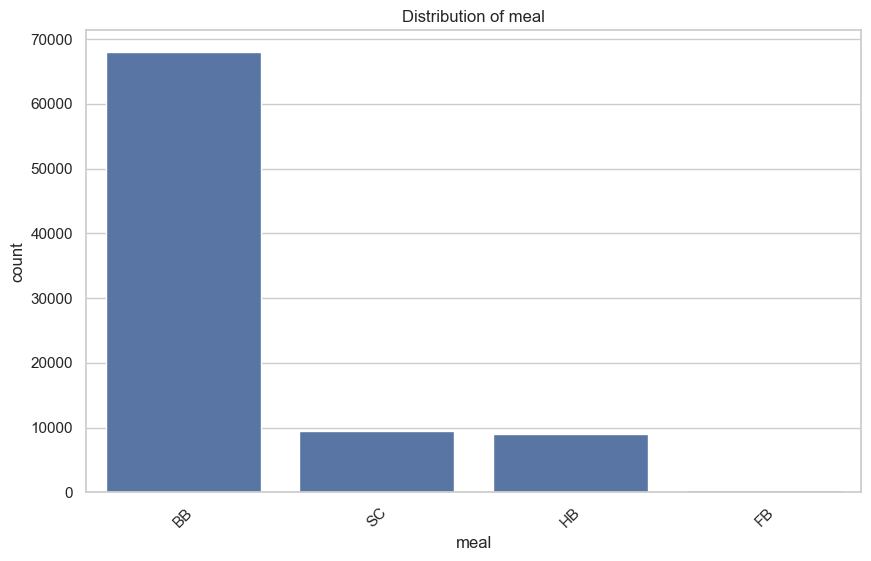

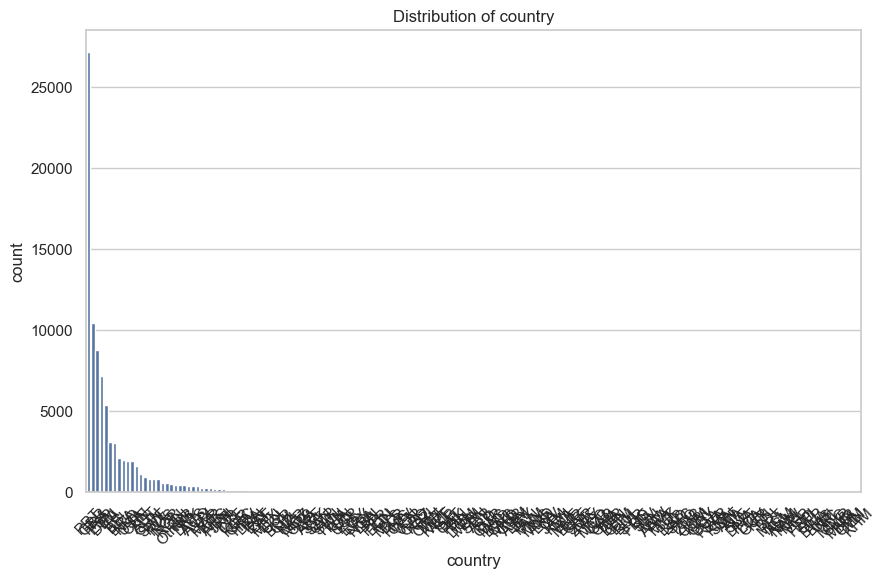

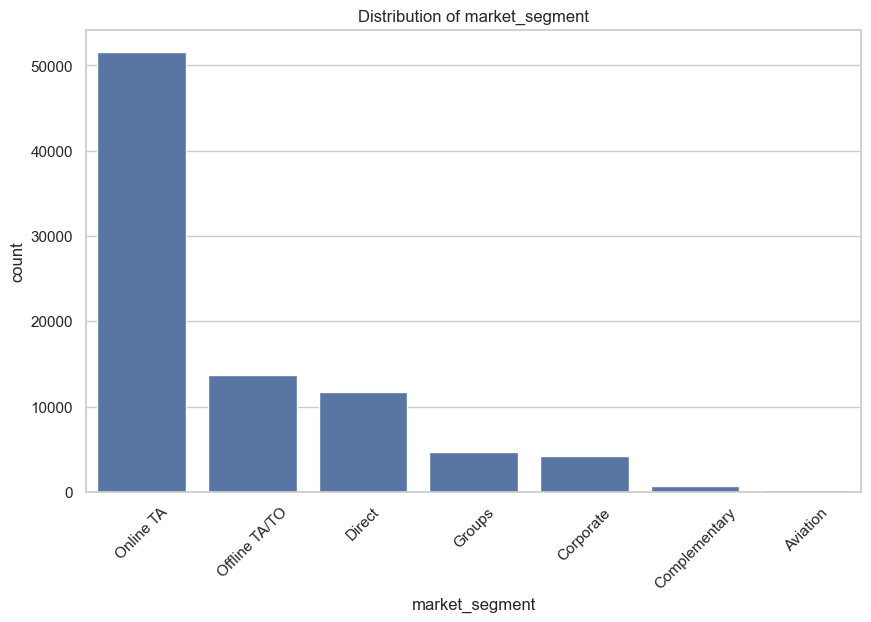

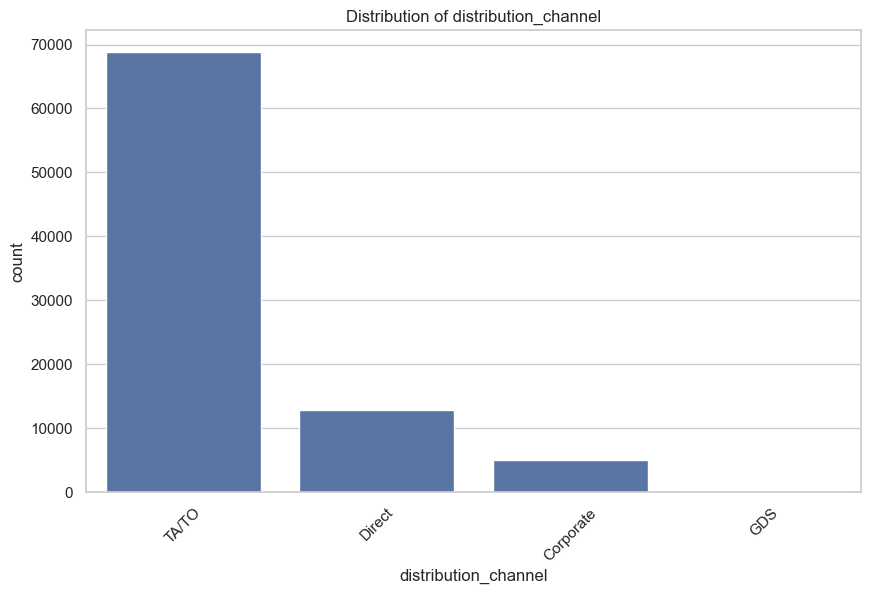

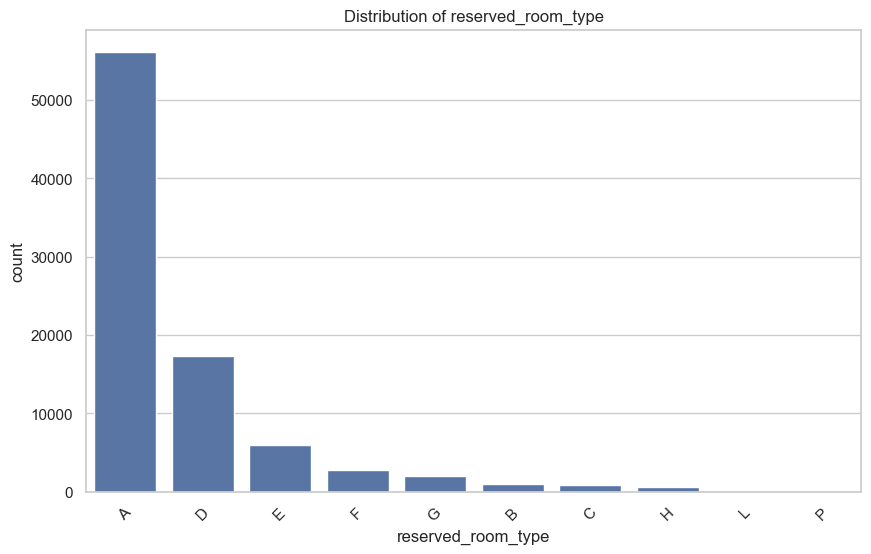

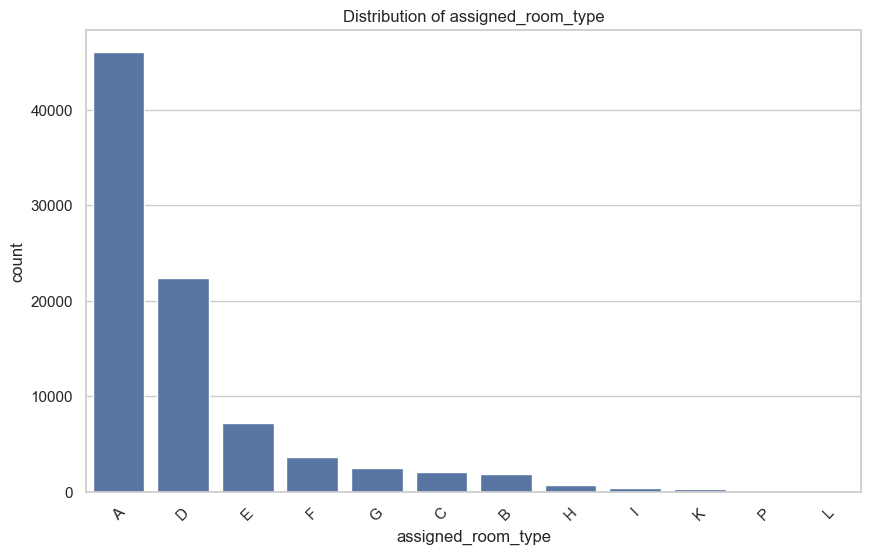

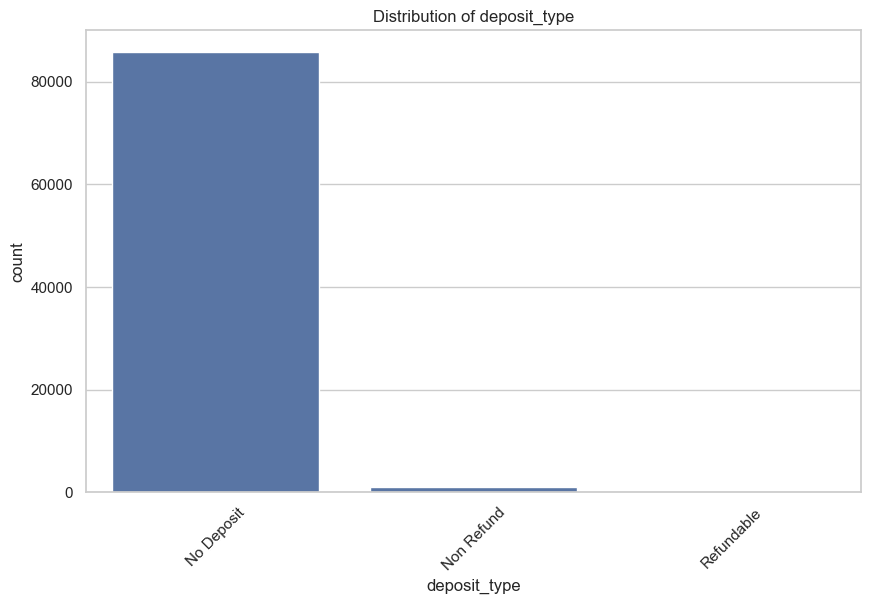

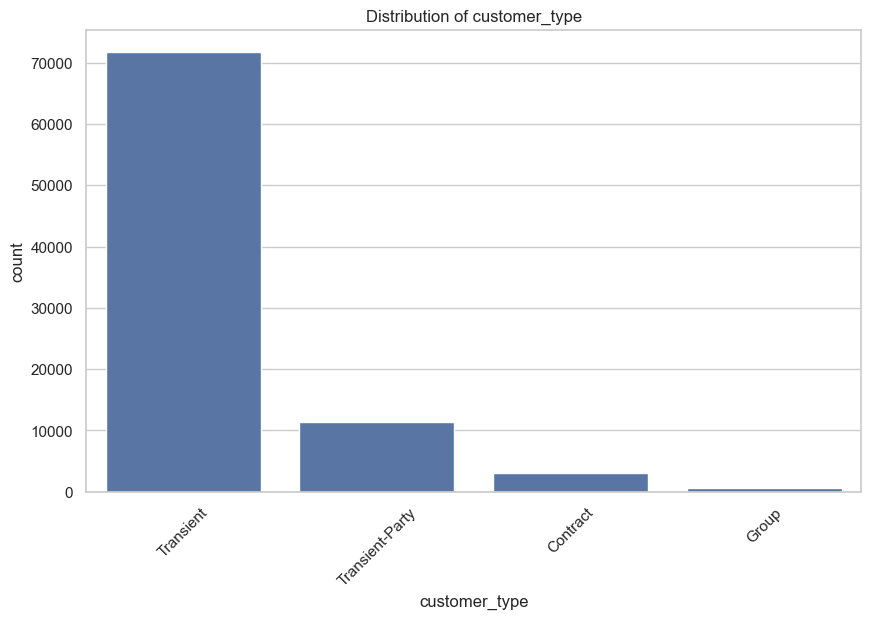

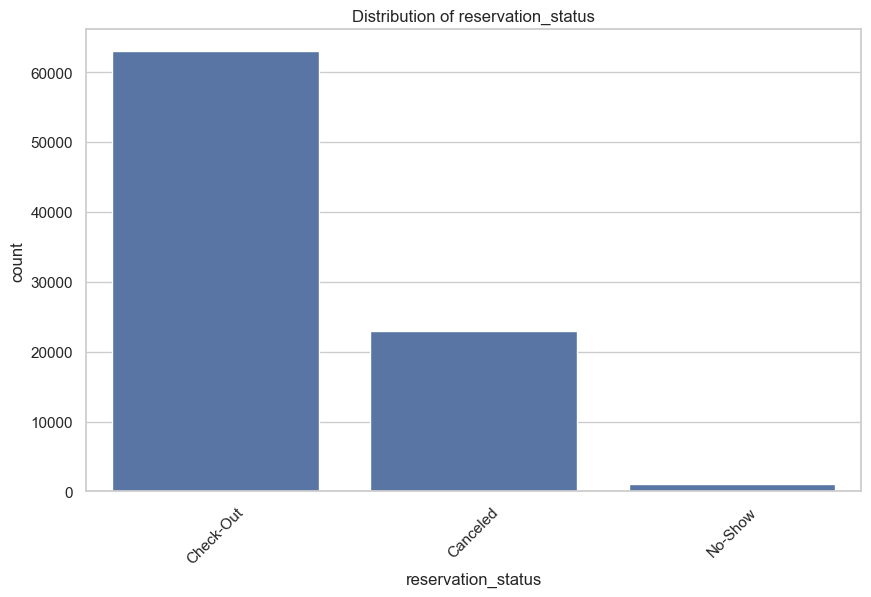

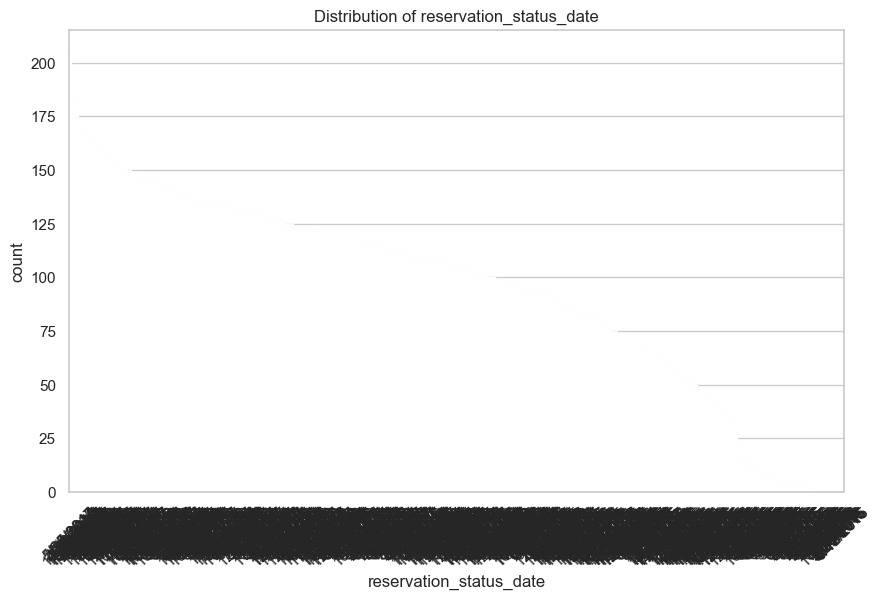

In [32]:
# Plot value counts for categorical features

for col in df.select_dtypes(include=['object']).columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


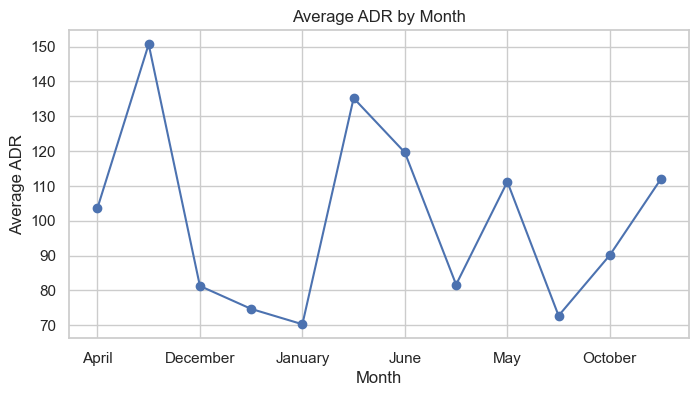

In [44]:
# Group by month and calculate average ADR
monthly_adr = df.groupby('arrival_date_month')['adr'].mean()

# Plot ADR trends over months
plt.figure(figsize=(8, 4))
monthly_adr.plot(kind='line', marker='o')
plt.title('Average ADR by Month')
plt.xlabel('Month')
plt.ylabel('Average ADR')
plt.show()


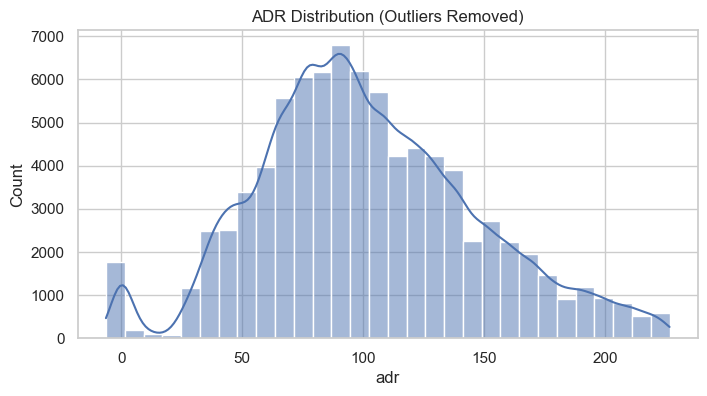

In [45]:
# Use IQR to detect outliers in ADR
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_filtered = df[(df['adr'] >= lower_bound) & (df['adr'] <= upper_bound)]

# Plot the distribution of ADR without outliers
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered['adr'], kde=True, bins=30)
plt.title('ADR Distribution (Outliers Removed)')
plt.show()


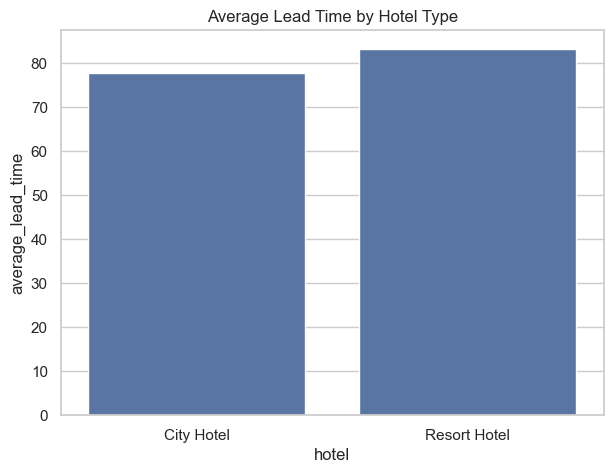

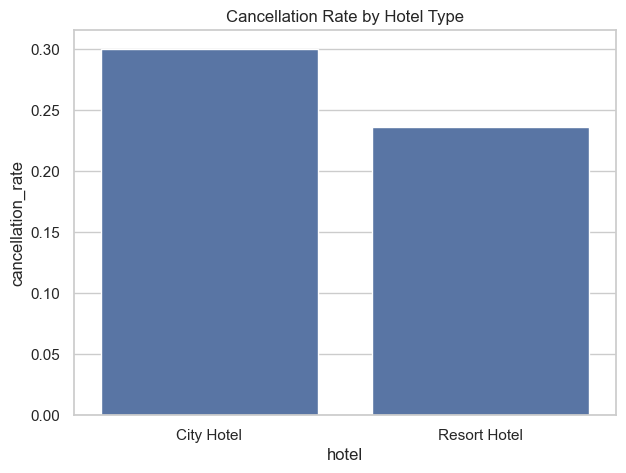

In [48]:
# Group by hotel type and calculate average lead time and cancellation rate
hotel_group = df.groupby('hotel').agg(
    average_lead_time=('lead_time', 'mean'),
    cancellation_rate=('is_canceled', lambda x: (x == 'yes').mean())
).reset_index()

# Plot grouped data
plt.figure(figsize=(7, 5))
sns.barplot(data=hotel_group, x='hotel', y='average_lead_time')
plt.title('Average Lead Time by Hotel Type')
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=hotel_group, x='hotel', y='cancellation_rate')
plt.title('Cancellation Rate by Hotel Type')
plt.show()


In [47]:
from scipy import stats

# Test if the cancellation rate is different between hotel types (t-test)
city_hotel = df[df['hotel'] == 'City Hotel']
resort_hotel = df[df['hotel'] == 'Resort Hotel']

t_stat, p_value = stats.ttest_ind(city_hotel['is_canceled'] == 'yes', resort_hotel['is_canceled'] == 'yes')

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: 20.76749250316869
P-value: 1.455834565664179e-95


# Feature Engineering

* Create text_length feature
* Encode categorical variables
* Drop irrelevant or ID columns
* Define feature set (X) and target (y)
* Scale numeric features
* Check result

In [ ]:

df['text_length'] = df['text'].fillna('').apply(len)


from sklearn.preprocessing import LabelEncoder

le_user = LabelEncoder()
df['user_id_encoded'] = le_user.fit_transform(df['user_id'])

le_device = LabelEncoder()
df['device_type_encoded'] = le_device.fit_transform(df['device_type'].astype(str))

df = pd.get_dummies(df, columns=['region'], drop_first=True)

drop_cols = ['Unnamed: 0', 'comment_id', 'recipe_name', 'user_name', 'text', 'device_type', 'user_id']
df.drop(columns=drop_cols, inplace=True)

X = df.drop('stars', axis=1)
y = df['stars']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(" Feature engineering complete!")
print(" Features shape:", X_scaled.shape)
display(X_scaled.head())


# Model Building

* Split the dataset (80% train, 20% test)
* Train Logistic Regression
* Train Random Forest Classifier
*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f" Train size: {X_train.shape}, Test size: {X_test.shape}")

lr_model = LogisticRegression(multi_class='multinomial', class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(" Models trained successfully.")


# Model Evaluation
*  Logistic Regression Evaluation
* Random Forest Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y.unique()))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

print(" Logistic Regression Evaluation")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))
plot_conf_matrix(y_test, lr_preds, "Logistic Regression – Confusion Matrix")

# 8.2 – Random Forest Evaluation
print(" Random Forest Evaluation")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
plot_conf_matrix(y_test, rf_preds, "Random Forest – Confusion Matrix")


# Evaluation Summary

# Logistic Regression

* Predicts across all classes (0–5), but performance is very poor.

* Class confusion is high: many 0–4 star ratings are predicted as 5.

* This model tries to generalize, but lacks predictive power.


# Random Forest

* Achieves high accuracy (76%) by predicting mostly class 5.

* Performs well for class 5 (precision = 77%, recall = 100%)

* Performs terribly for classes 0–4 (recall ≈ 0 for class 2, 3, 4)

* Fails to generalize → acts like a 1-class classifier



In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

rf_report_dict = classification_report(y_test, rf_preds, output_dict=True)

rf_report_df = pd.DataFrame(rf_report_dict).transpose()

rf_report_df = rf_report_df.round(2)

display(rf_report_df.loc[['0', '1', '2', '3', '4', '5']])


# Apply SMOTE to Balance the Classes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f" Split done | Train: {X_train.shape} | Test: {X_test.shape}")

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)
print(" SMOTE class distribution:\n", pd.Series(y_train_smote).value_counts().sort_index())

lr_model_smote = LogisticRegression(multi_class='multinomial', max_iter=1000, n_jobs=None)
lr_model_smote.fit(X_train_smote, y_train_smote)
lr_preds_smote = lr_model_smote.predict(X_test)

rf_model_smote = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model_smote.fit(X_train_smote, y_train_smote)
rf_preds_smote = rf_model_smote.predict(X_test)

def plot_conf_matrix(y_true, y_pred, title):
    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

print("\n Logistic Regression after SMOTE")
print("Accuracy:", accuracy_score(y_test, lr_preds_smote))
print(classification_report(y_test, lr_preds_smote, digits=2))
plot_conf_matrix(y_test, lr_preds_smote, "Logistic Regression (SMOTE) – Confusion Matrix")

print("\n Random Forest after SMOTE")
print("Accuracy:", accuracy_score(y_test, rf_preds_smote))
print(classification_report(y_test, rf_preds_smote, digits=2))
plot_conf_matrix(y_test, rf_preds_smote, "Random Forest (SMOTE) – Confusion Matrix")

try:
    importances = pd.Series(rf_model_smote.feature_importances_, index=X_scaled.columns).sort_values(ascending=False)
    print("\n Top 10 Feature Importances (Random Forest):")
    display(importances.head(10))
except Exception as e:
    print("Could not compute feature importances:", e)



# Business Insights and Recommendations